# #100DaysOfCode - Day 99 Challenge - Analyse and Visualise the Space Race

# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

# Space Missions Analysis

This completed notebook analyzes the historical space mission launch dataset from 1957 to 2020. The workflow moves from setup and inspection into cleaning, feature engineering, visual analysis, key findings, and reflection.

## Setup & Imports

In [1]:
# Purpose:
# Import the libraries used for data cleaning, summary tables, and visualization.
# The plotting defaults keep chart styling consistent throughout the notebook.

import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

sns.set_palette('tab10')
px.defaults.template = 'plotly_dark'

print('Libraries imported and plotting style configured.')

Libraries imported and plotting style configured.


# First look at the data

In [2]:
df_raw = pd.read_csv('mission_launches.csv')
unnamed_columns = df_raw.columns[df_raw.columns.str.contains(r'^Unnamed')]
df = df_raw.drop(columns=unnamed_columns).copy()

df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [3]:
print(df.shape)
print()
df.dtypes

(4324, 7)



Organisation      object
Location          object
Date              object
Detail            object
Rocket_Status     object
Price             object
Mission_Status    object
dtype: object

In [4]:
print('Missing values:')
print(df.isna().sum())
print()
df.tail()

Missing values:
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64



,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success
4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success


In [5]:
csv_path = 'mission_launches.csv'
df_raw = pd.read_csv(csv_path)

unnamed_columns = df_raw.columns[df_raw.columns.str.contains(r'^Unnamed')]
df = df_raw.drop(columns=unnamed_columns).copy()

print(f'Original shape: {df_raw.shape}')
print(f'Shape after dropping unnamed index columns: {df.shape}')
print(f'Dropped columns: {list(unnamed_columns)}')
print()
print('Column data types:')
print(df.dtypes)
print()
print('Missing value counts:')
print(df.isna().sum())

print()
print('First five rows:')
display(df.head(5))

Original shape: (4324, 9)
Shape after dropping unnamed index columns: (4324, 7)
Dropped columns: ['Unnamed: 0.1', 'Unnamed: 0']

Column data types:
Organisation      object
Location          object
Date              object
Detail            object
Rocket_Status     object
Price             object
Mission_Status    object
dtype: object

Missing value counts:
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

First five rows:


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


## Data Cleaning & Feature Engineering

In [6]:
# Purpose:
# Parse launch dates, extract year/month/country features, convert launch price
# to numeric USD millions, and define mission failure flags for later analysis.

# Parse the common date-time format first. Some older records omit the time and
# UTC suffix, so a second pass handles those shorter date strings.
df['Date_Parsed'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
missing_date_mask = df['Date_Parsed'].isna()
df.loc[missing_date_mask, 'Date_Parsed'] = pd.to_datetime(
    df.loc[missing_date_mask, 'Date'],
    utc=True,
    errors='coerce',
    format='%a %b %d, %Y'
)


df['Year'] = df['Date_Parsed'].dt.year.astype(int)
df['Month'] = df['Date_Parsed'].dt.month.astype(int)
df['Country'] = df['Location'].str.split(', ').str[-1].str.strip()

# Convert Price to numeric USD millions, missing values stay as nan and are
# excluded only from cost specific charts.
df['Price'] = pd.to_numeric(
    df['Price'].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)

# Treat Success as success and every other mission status as a failure category.
df['Mission_Result'] = np.where(df['Mission_Status'].eq('Success'), 'Success', 'Failure')
df['Is_Failure'] = df['Mission_Status'].ne('Success')
df['Decade'] = (df['Year'] // 10) * 10

cleaning_summary = pd.DataFrame({
    'Metric': [
        'Rows after cleaning',
        'Columns after feature engineering',
        'Unparsed dates',
        'Rows with launch price available',
        'Rows missing launch price',
        'Overall failure rate (%)'
    ],
    'Value': [
        len(df),
        df.shape[1],
        int(df['Date_Parsed'].isna().sum()),
        int(df['Price'].notna().sum()),
        int(df['Price'].isna().sum()),
        round(df['Is_Failure'].mean() * 100, 2)
    ]
})

display(cleaning_summary)
display(df[['Organisation', 'Location', 'Country', 'Date', 'Year', 'Month', 'Price', 'Mission_Status', 'Is_Failure']].head(5))

,Metric,Value
0,Rows after cleaning,"4,324.00"
1,Columns after feature engineering,14.00
2,Unparsed dates,0.00
3,Rows with launch price available,964.00
4,Rows missing launch price,"3,360.00"
5,Overall failure rate (%),10.29


,Organisation,Location,Country,Date,Year,Month,Price,Mission_Status,Is_Failure
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",USA,"Fri Aug 07, 2020 05:12 UTC",2020,8,50.00,Success,False
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",China,"Thu Aug 06, 2020 04:01 UTC",2020,8,29.75,Success,False
2,SpaceX,"Pad A, Boca Chica, Texas, USA",USA,"Tue Aug 04, 2020 23:57 UTC",2020,8,NaN,Success,False
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,"Thu Jul 30, 2020 21:25 UTC",2020,7,65.00,Success,False
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",USA,"Thu Jul 30, 2020 11:50 UTC",2020,7,145.00,Success,False


# Required Questions

## Q1 - Who launched the most missions in any given year?

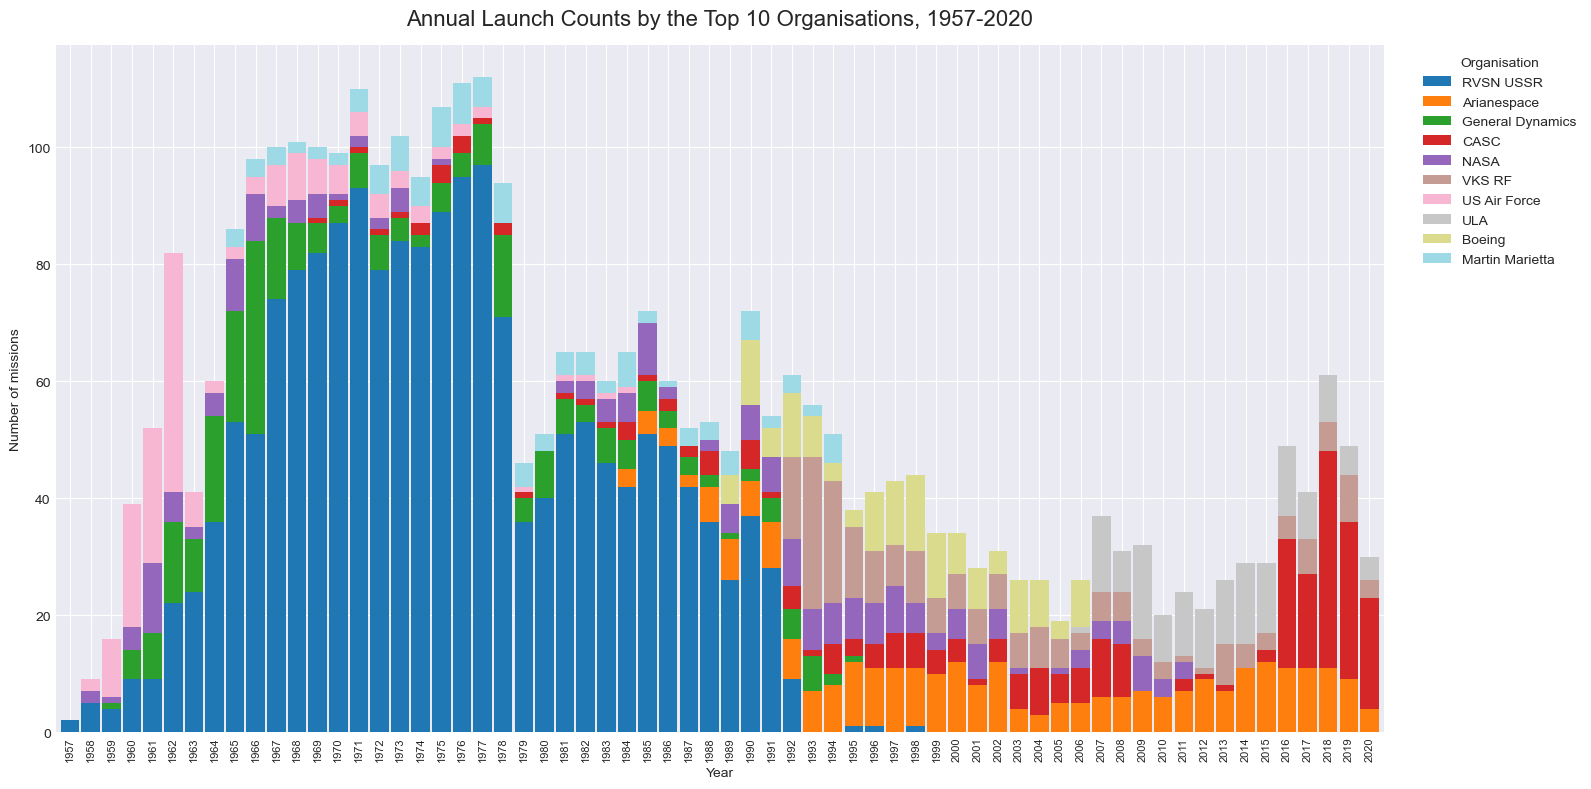

Top 10 organisations by total launches:


,Total Launches
Organisation,
RVSN USSR,1777
Arianespace,279
General Dynamics,251
CASC,251
NASA,203
VKS RF,201
US Air Force,161
ULA,140
Boeing,136


Highest single-year launch totals:


,Year,Organisation,Launches
139,1977,RVSN USSR,97
132,1976,RVSN USSR,95
93,1971,RVSN USSR,93
125,1975,RVSN USSR,89
80,1970,RVSN USSR,87
108,1973,RVSN USSR,84
115,1974,RVSN USSR,83
67,1969,RVSN USSR,82
60,1968,RVSN USSR,79
101,1972,RVSN USSR,79


Leading organisation by decade:


,Decade,Organisation,Launches
5,1950,US Navy,17
15,1960,RVSN USSR,439
31,1970,RVSN USSR,814
48,1980,RVSN USSR,436
72,1990,VKS RF,104
75,2000,Arianespace,68
102,2010,CASC,108
132,2020,CASC,19


In [7]:
# Purpose:
# Build a Year x Organisation launch-count pivot table, keep the top 10
# organisations by total launches, and plot annual launch counts as a stacked bar chart.

launch_pivot = df.pivot_table(
    index='Year',
    columns='Organisation',
    values='Detail',
    aggfunc='count',
    fill_value=0
)

top_10_organisations = launch_pivot.sum(axis=0).sort_values(ascending=False).head(10).index
launch_pivot_top10 = launch_pivot[top_10_organisations]

fig, ax = plt.subplots(figsize=(16, 8))
launch_pivot_top10.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.9)
ax.set_title('Annual Launch Counts by the Top 10 Organisations, 1957-2020', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of missions')
ax.legend(title='Organisation', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

yearly_org_counts = df.groupby(['Year', 'Organisation']).size().reset_index(name='Launches')
yearly_leaders = yearly_org_counts.sort_values(['Year', 'Launches'], ascending=[True, False]).groupby('Year').head(1)
decade_leaders = (
    df.groupby(['Decade', 'Organisation'])
      .size()
      .reset_index(name='Launches')
      .sort_values(['Decade', 'Launches'], ascending=[True, False])
      .groupby('Decade')
      .head(1)
)

print('Top 10 organisations by total launches:')
display(launch_pivot.sum(axis=0).sort_values(ascending=False).head(10).to_frame('Total Launches'))
print('Highest single-year launch totals:')
display(yearly_org_counts.sort_values('Launches', ascending=False).head(10))
print('Leading organisation by decade:')
display(decade_leaders)

**Conclusion:** RVSN USSR dominated the dataset by launch volume, especially during the 1960s, 1970s, and 1980s. Its strongest decade was the 1970s with 814 launches, and the highest single organisation-year was RVSN USSR in 1977 with 97 launches. Later decades became more distributed: VKS RF led the 1990s, Arianespace led the 2000s, and CASC led the 2010s.

## Q2 - How has the cost of a space mission varied over time?

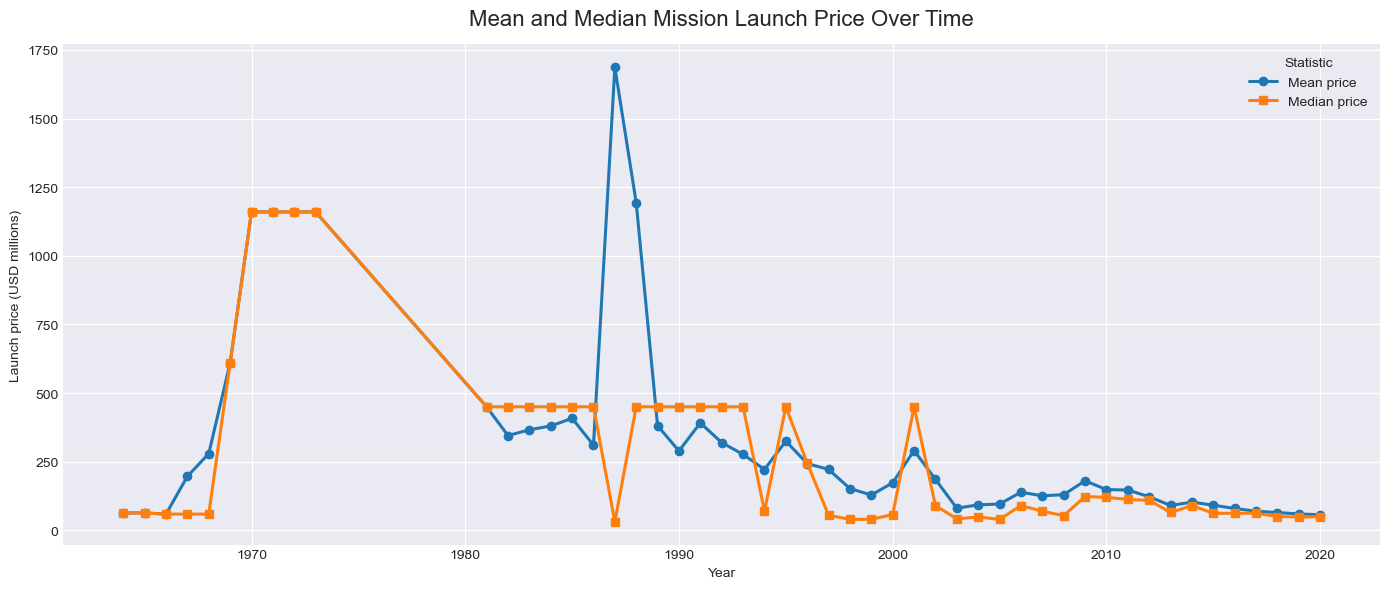

Cost chart uses 964 missions with non-missing price values out of 4324 total missions.
Highest annual mean prices:


,Year,mean_price_musd,median_price_musd,priced_launches
16,1987,"1,687.20",30.80,3
17,1988,"1,193.16",450.00,5
9,1973,"1,160.00","1,160.00",1
6,1970,"1,160.00","1,160.00",1
7,1971,"1,160.00","1,160.00",2
8,1972,"1,160.00","1,160.00",2
5,1969,609.50,609.50,8
10,1981,450.00,450.00,2


Most recent annual cost statistics:


,Year,mean_price_musd,median_price_musd,priced_launches
40,2011,146.60,112.50,29
41,2012,122.29,109.00,25
42,2013,90.55,65.00,33
43,2014,102.55,90.00,41
44,2015,91.55,62.00,39
45,2016,79.46,62.00,64
46,2017,69.49,62.00,66
47,2018,64.75,50.00,88
48,2019,59.61,48.50,73
49,2020,56.65,49.25,52


In [8]:
# Purpose:
# Use only rows with known prices, then compare annual mean and median launch
# price in USD millions to show both the average trend and the effect of outliers.

cost_df = df.dropna(subset=['Price']).copy()
cost_by_year = (
    cost_df.groupby('Year')['Price']
           .agg(mean_price_musd='mean', median_price_musd='median', priced_launches='count')
           .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cost_by_year['Year'], cost_by_year['mean_price_musd'], marker='o', linewidth=2.2, label='Mean price')
ax.plot(cost_by_year['Year'], cost_by_year['median_price_musd'], marker='s', linewidth=2.2, label='Median price')
ax.set_title('Mean and Median Mission Launch Price Over Time', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Launch price (USD millions)')
ax.legend(title='Statistic')
plt.tight_layout()
plt.show()

print(f'Cost chart uses {len(cost_df)} missions with non-missing price values out of {len(df)} total missions.')
print('Highest annual mean prices:')
display(cost_by_year.sort_values('mean_price_musd', ascending=False).head(8))
print('Most recent annual cost statistics:')
display(cost_by_year.tail(10))

**Conclusion:** Price data is available for 964 missions, so this chart should be read as a cost trend for the priced subset, not the entire dataset. The largest mean spike appears in 1987 at about $1,687.20 million, while the 1970-1973 period has very high medians of $1,160.00 million. By the late 2010s the typical priced launch was much lower: the 2020 mean was about $56.65 million and the median was $49.25 million. The long-term pattern suggests that priced launches became much less expensive in the commercial era, although missing price data limits the certainty of that conclusion.

## Q3 - Which months are the most popular for launches?

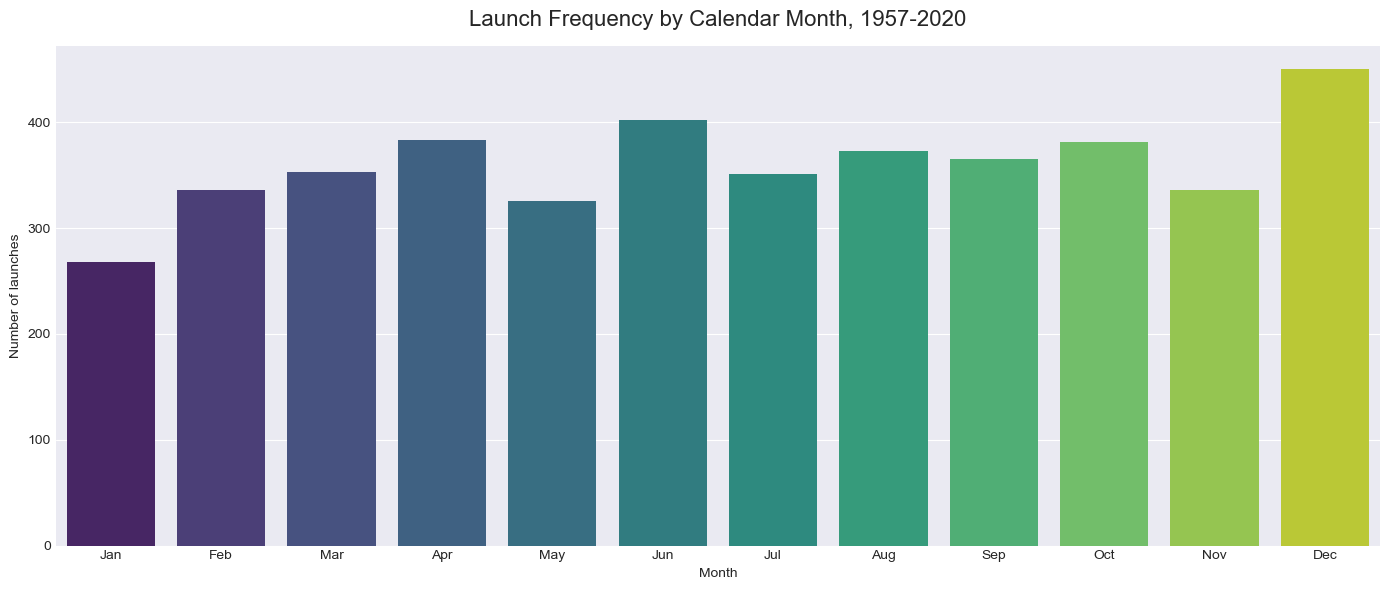

,Month,Launches,Month_Name
0,1,268,Jan
1,2,336,Feb
2,3,353,Mar
3,4,383,Apr
4,5,326,May
5,6,402,Jun
6,7,351,Jul
7,8,373,Aug
8,9,365,Sep
9,10,381,Oct


In [9]:
# Purpose:
# Count launches by calendar month and plot the months in Jan-Dec order rather
# than sorting by frequency.

month_counts = df['Month'].value_counts().reindex(range(1, 13), fill_value=0).rename_axis('Month').reset_index(name='Launches')
month_counts['Month_Name'] = month_counts['Month'].apply(lambda m: calendar.month_abbr[m])

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=month_counts, x='Month_Name', y='Launches', ax=ax, palette='viridis')
ax.set_title('Launch Frequency by Calendar Month, 1957-2020', fontsize=16, pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of launches')
plt.tight_layout()
plt.show()

display(month_counts)

**Conclusion:** December is the most popular launch month with 450 launches, followed by June with 402 launches. January is the slowest month with 268 launches. The pattern is not evenly seasonal, but the data shows a clear end-of-year push and a smaller mid-year peak, while the beginning of the year is comparatively quiet.

## Q4 - Have space missions become safer over time?

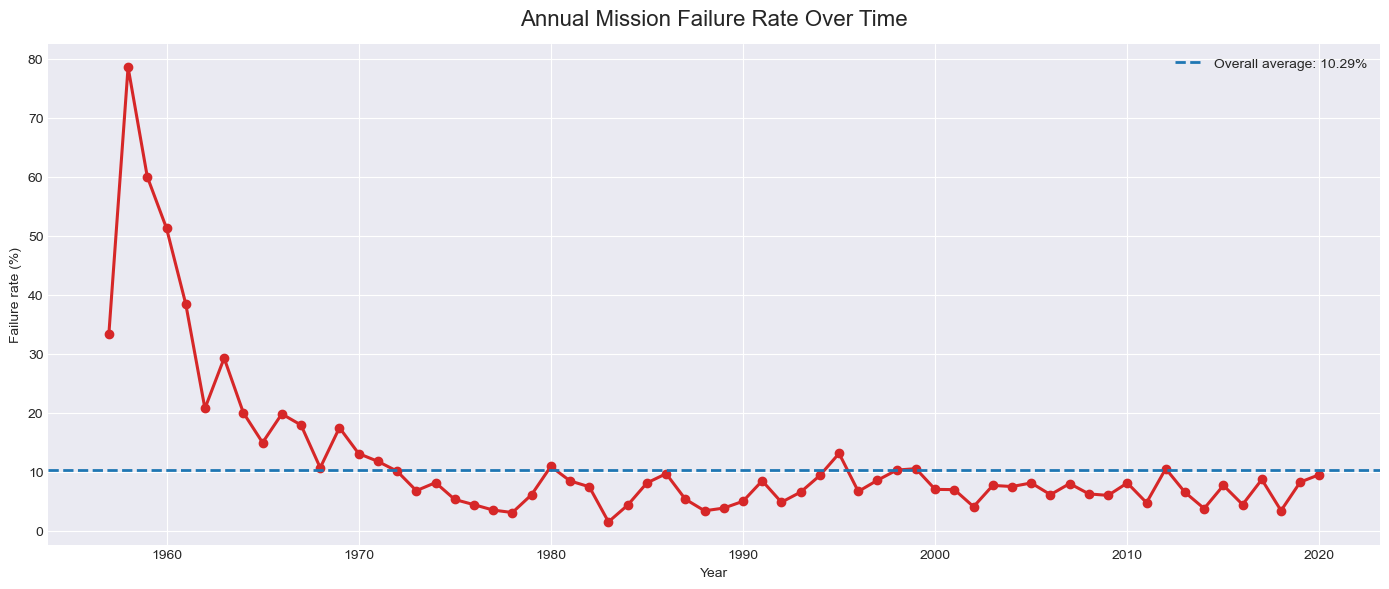

Failure rate by decade:


,Decade,total_missions,failures,failure_rate_pct
0,1950,51,35,68.63
1,1960,774,162,20.93
2,1970,1012,74,7.31
3,1980,631,40,6.34
4,1990,642,53,8.26
5,2000,475,32,6.74
6,2010,676,43,6.36
7,2020,63,6,9.52


In [10]:
# Purpose:
# Calculate yearly mission failure rates and compare them with the overall
# average failure rate to evaluate whether mission reliability improved over time.

failure_by_year = (
    df.groupby('Year')
      .agg(total_missions=('Detail', 'size'), failures=('Is_Failure', 'sum'))
      .reset_index()
)
failure_by_year['failure_rate_pct'] = failure_by_year['failures'] / failure_by_year['total_missions'] * 100
overall_failure_rate = df['Is_Failure'].mean() * 100

failure_by_decade = (
    df.groupby('Decade')
      .agg(total_missions=('Detail', 'size'), failures=('Is_Failure', 'sum'))
      .reset_index()
)
failure_by_decade['failure_rate_pct'] = failure_by_decade['failures'] / failure_by_decade['total_missions'] * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(failure_by_year['Year'], failure_by_year['failure_rate_pct'], color='#d62728', marker='o', linewidth=2.2)
ax.axhline(overall_failure_rate, color='#1f77b4', linestyle='--', linewidth=2, label=f'Overall average: {overall_failure_rate:.2f}%')
ax.set_title('Annual Mission Failure Rate Over Time', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Failure rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print('Failure rate by decade:')
display(failure_by_decade)

**Conclusion:** Space missions did become safer over time. The early space race was very risky: the 1950s had a 68.63% failure rate and the 1960s had a 20.93% failure rate. From the 1970s onward, decade-level failure rates mostly stayed below the overall average of 10.29%, including 7.31% in the 1970s, 6.34% in the 1980s, 6.74% in the 2000s, and 6.36% in the 2010s. The 2020 value rises to 9.52%, but it is based on only part of a year in this dataset.

## Two Additional Insights

## Insight A - Country-level launch activity over time

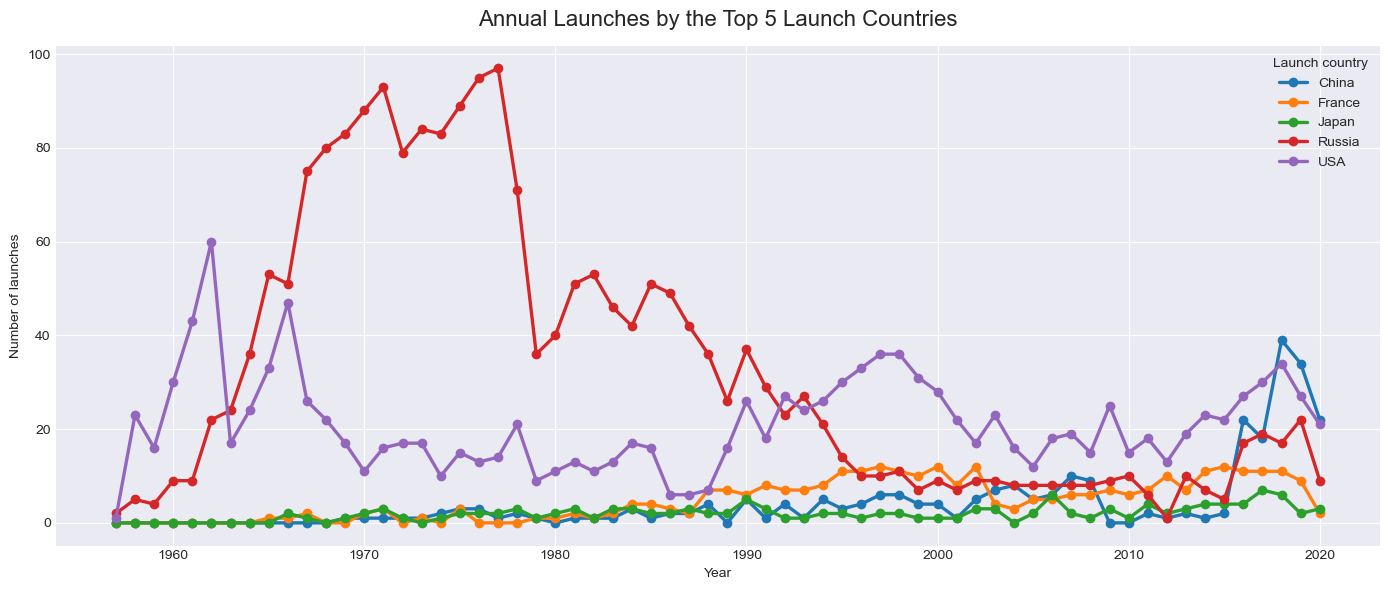

Top 5 launch countries after standardisation:


,Total Launches
Launch_Country,
Russia,2099
USA,1349
France,303
China,269
Japan,126


Peak year for each top country:


,Year,Launch_Country,Launches
66,1977,Russia,97
11,1962,USA,60
262,2018,China,39
161,1997,France,12
259,2017,Japan,7


In [11]:
# Purpose:
# Standardise launch country labels, map Baikonur/Kazakhstan launches to Russia
# for historical comparison, and plot annual launch activity for the top 5 countries.

country_standardisation = {
    'New Mexico': 'USA',
    'Pacific Missile Range Facility': 'USA',
    'Yellow Sea': 'China',
    'Barents Sea': 'Russia',
    'Shahrud Missile Test Site': 'Iran',
    'Gran Canaria': 'Spain',
    'Pacific Ocean': 'Sea Launch Platform'
}

df['Launch_Country'] = df['Country'].replace(country_standardisation)
df.loc[
    df['Country'].eq('Kazakhstan') & df['Location'].str.contains('Baikonur', case=False, na=False),
    'Launch_Country'
] = 'Russia'

top_5_countries = df['Launch_Country'].value_counts().head(5).index
country_year = (
    df[df['Launch_Country'].isin(top_5_countries)]
      .groupby(['Year', 'Launch_Country'])
      .size()
      .reset_index(name='Launches')
)
country_year_pivot = country_year.pivot(index='Year', columns='Launch_Country', values='Launches').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
country_year_pivot.plot(ax=ax, linewidth=2.4, marker='o')
ax.set_title('Annual Launches by the Top 5 Launch Countries', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of launches')
ax.legend(title='Launch country')
plt.tight_layout()
plt.show()

print('Top 5 launch countries after standardisation:')
display(df['Launch_Country'].value_counts().head(5).to_frame('Total Launches'))
print('Peak year for each top country:')
peak_country_years = country_year.loc[country_year.groupby('Launch_Country')['Launches'].idxmax()].sort_values('Launches', ascending=False)
display(peak_country_years)

**Conclusion:** Country-level launch activity reflects the Cold War space race strongly. Russia, including Baikonur launches, has 2,099 launches and peaks at 97 launches in 1977, while the USA has 1,351 launches and peaks at 60 launches in 1962. China appears earlier in the data, but it becomes much more visible in the modern period: it reaches 10 launches in 2007 and then jumps to 22 in 2016, 39 in 2018, 34 in 2019, and 22 in 2020. That shift shows China becoming a major launch country toward the end of the dataset.

## Insight B - Private vs Government organisations

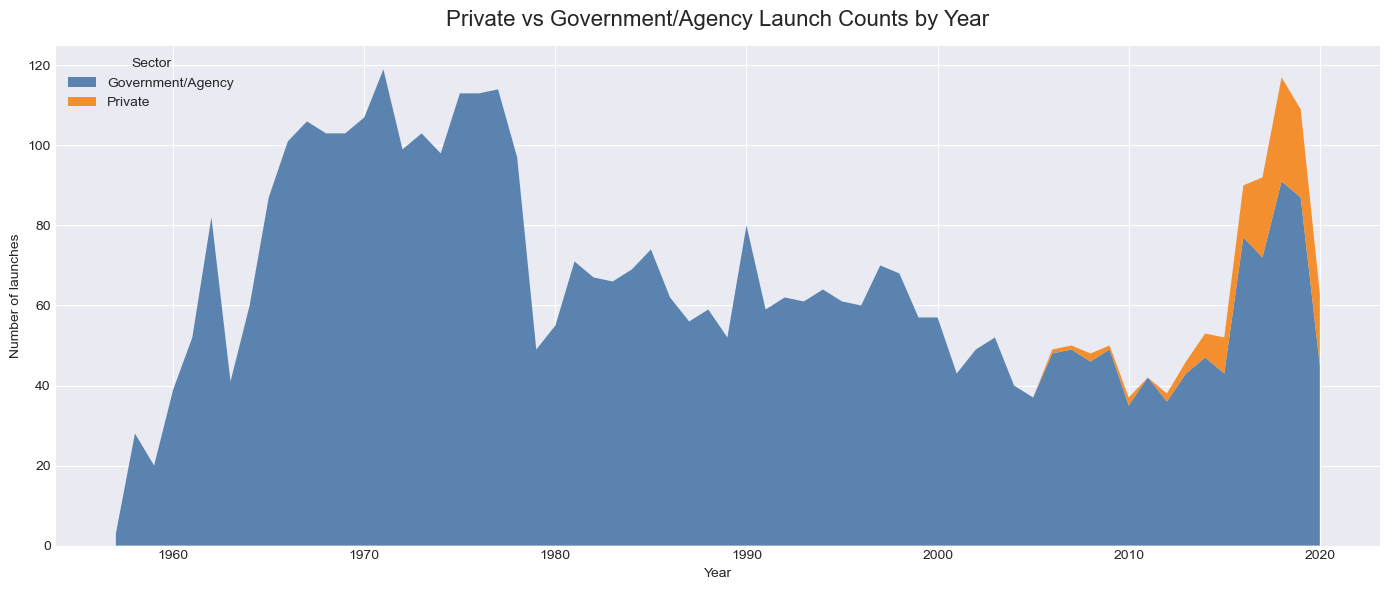

Years with private launches:


,Private Launches,Private Share (%)
Year,,
2006,1.00,2.04
2007,1.00,2.00
2008,2.00,4.17
2009,1.00,2.00
2010,2.00,5.41
2012,2.00,5.26
2013,3.00,6.52
2014,6.00,11.32
2015,9.00,17.31


In [12]:
# Purpose:
# Classify selected modern commercial launch organisations as Private and all
# other organisations as Government/Agency, then compare annual launch counts.

private_organisations = {'SpaceX', 'Rocket Lab', 'Virgin Orbit', 'Blue Origin'}
df['Sector'] = np.where(df['Organisation'].isin(private_organisations), 'Private', 'Government/Agency')

sector_year = (
    df.groupby(['Year', 'Sector'])
      .size()
      .reset_index(name='Launches')
)
sector_year_pivot = sector_year.pivot(index='Year', columns='Sector', values='Launches').fillna(0)
sector_year_pivot = sector_year_pivot.reindex(columns=['Government/Agency', 'Private'], fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    sector_year_pivot.index,
    sector_year_pivot['Government/Agency'],
    sector_year_pivot['Private'],
    labels=['Government/Agency', 'Private'],
    colors=['#4c78a8', '#f58518'],
    alpha=0.9
)
ax.set_title('Private vs Government/Agency Launch Counts by Year', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of launches')
ax.legend(loc='upper left', title='Sector')
plt.tight_layout()
plt.show()

private_by_year = sector_year_pivot['Private']
private_share = (private_by_year / sector_year_pivot.sum(axis=1) * 100).rename('Private Share (%)')
private_summary = pd.DataFrame({
    'Private Launches': private_by_year,
    'Private Share (%)': private_share
}).query('`Private Launches` > 0')

print('Years with private launches:')
display(private_summary)

**Conclusion:** Private launches start appearing in this classification in 2006, but they become significant around 2014, when private organisations reach 6 launches and 11.32% of annual launch activity. The private count then grows quickly, reaching 26 launches in 2018 and 18 launches in 2020. By 2020, private launches represent 28.57% of launches in the dataset, showing how strongly the launch market shifted toward commercial providers near the end of the period.

## Key Findings

**Q1 - Who launched the most missions in any given year?** RVSN USSR was the clear leader in launch volume, especially during the Cold War decades. It led the 1960s with 439 launches, the 1970s with 814 launches, and the 1980s with 436 launches. The biggest single organisation-year was RVSN USSR in 1977 with 97 launches, which shows how concentrated launch activity was during the height of the Soviet launch program.

**Q2 - How has the cost of a space mission varied over time?** Cost varies sharply, but the available price data covers only 964 of the 4,324 missions. The most extreme annual mean occurs in 1987 at around USD 1,687.20 million, and the 1970-1973 medians sit at USD 1,160.00 million. In contrast, recent priced launches are much cheaper in the data: 2020 has a mean of about USD 56.65 million and a median of USD 49.25 million. The overall pattern suggests a move away from very expensive government-era launches toward lower-cost modern launches, while missing price values remain an important limitation.

**Q3 - Which months are the most popular for launches?** December is the most active launch month with 450 launches, and January is the slowest with 268 launches. June is also high with 402 launches. This suggests that launches are not evenly distributed through the year; there is a clear end-of-year concentration and a smaller mid-year peak.

**Q4 - Have space missions become safer over time?** Yes. The failure rate falls from 68.63% in the 1950s and 20.93% in the 1960s to mostly single-digit rates after 1970. The 1970s have a 7.31% failure rate, the 1980s 6.34%, the 2000s 6.74%, and the 2010s 6.36%. The overall average is 10.29%, so most later decades sit below the dataset-wide risk level.

**Insight A - Country-level launch activity over time.** After standardising country labels and mapping Baikonur launches to Russia, Russia has the highest total with 2,099 launches, followed by the USA with 1,351. This captures the Cold War launch race: Russia peaks at 97 launches in 1977, while the USA peaks earlier at 60 launches in 1962. China becomes much more visible late in the dataset, reaching 10 launches in 2007 and then surging to 39 launches in 2018.

**Insight B - Private vs Government organisations.** Private launches are small at first, beginning in 2006 in this classification, but they become significant by 2014 with 6 launches and 11.32% of annual launches. They peak at 26 launches in 2018 and account for 28.57% of launches in 2020. This shows a major shift toward commercial launch providers near the end of the dataset.

**Most surprising trend.** The most surprising trend is how quickly the dataset changes in the 2010s. The early story is dominated by government space-race activity, especially RVSN USSR, but the later story includes both the rise of China and the rapid growth of private launch providers. The data makes the Space Race feel less like one fixed historical period and more like several different launch eras stacked on top of each other.

## Reflection

I approached this project by first getting familiar with the raw dataset instead of jumping straight into charts. I started by loading the CSV, checking its shape, reviewing the column types, looking at the first rows, and counting missing values. After that, I focused on cleaning because the visual analysis depended on having reliable Year, Month, Country, Price, and mission outcome fields. Once those features were ready, I built each chart around a specific question and used the grouped values to write conclusions from the actual data.

The easiest parts were loading the data and doing the basic groupings, such as counting launches by organisation, year, or month. Pandas made those summaries fairly direct once the columns were clean. The more challenging parts were the details that looked simple at first but needed care. The Date column had mostly full date-time strings, but some rows did not include a time or UTC label, so I needed a fallback parsing step. Extracting countries from Location also required attention because the final segment was not always a clean country name. The Price column was another challenge because most rows were missing prices, so I kept those rows for general analysis but excluded them from cost charts.

This project was a good reminder of how far things have come. We're at day 99 of 100 Days of Code, and looking back at everything covered in these two years, this one felt pretty comfortable. Data is my area, so loading a CSV, cleaning columns, grouping by year and plotting trends is familiar ground. The ones that really pushed me were the automation projects and the more complex pipeline stuff, those took a lot more trial and error to get right.
That said, it was still satisfying to put it all together in one notebook and watch the Space Race story emerge from the data. Seeing Russia's launch dominance in the 70s, the drop-off after the Cold War, China quietly showing up in the 2000s and then surging, and SpaceX basically rewriting what a launch company looks like by 2018, all of that came through clearly in the charts.

**Almost at the finish line now. Hope you enjoyed following along through all 100 days :)**